In [106]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

In [107]:
df=pd.read_csv('creditcard.csv')

In [108]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [109]:
df.shape

(284807, 31)

In [110]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [111]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [112]:
df['Class'].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

<Axes: xlabel='Class', ylabel='count'>

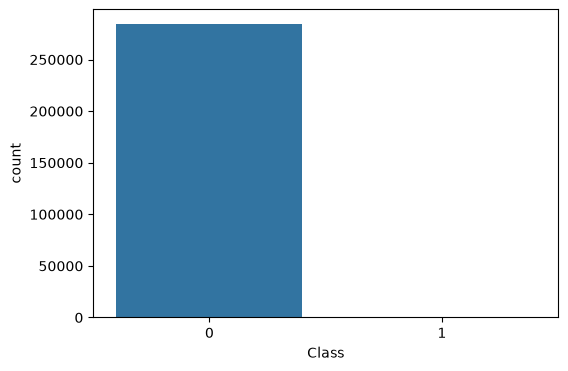

In [113]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Class")

<Axes: xlabel='Amount', ylabel='Count'>

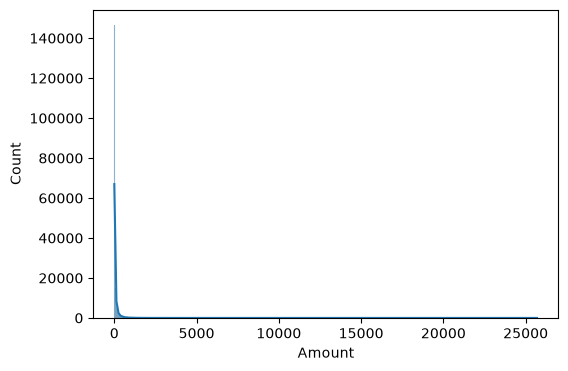

In [114]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x="Amount", kde=True)

In [115]:
df["Amount"].max()

np.float64(25691.16)

<Axes: xlabel='Class', ylabel='Amount'>

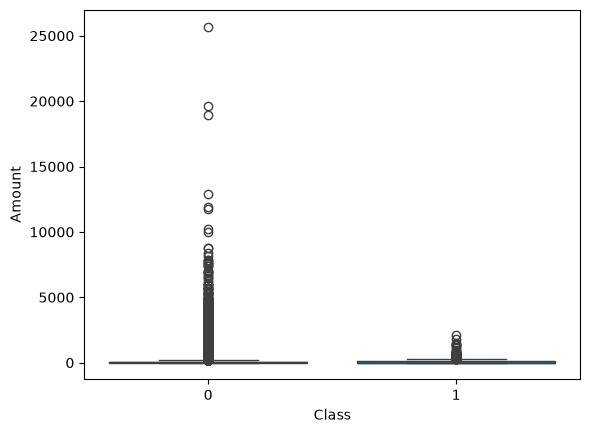

In [116]:
sns.boxplot(data=df, x='Class', y='Amount') 

In [117]:
from sklearn.preprocessing import StandardScaler

In [118]:
scaler=StandardScaler()

In [119]:
from sklearn.model_selection import train_test_split

In [120]:
X = df.drop(columns=['Class']) 
y = df['Class'] 
  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [121]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[['Time', 'Amount']] = scaler.fit_transform(
    X_train[['Time', 'Amount']]
)

X_test_scaled[['Time', 'Amount']] = scaler.transform(
    X_test[['Time', 'Amount']]
)

In [122]:
from sklearn.utils.class_weight import compute_class_weight
weight=compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)

In [123]:
class_weight_dict={0:weight[0],1:weight[1]}
print(class_weight_dict)

{0: np.float64(0.5008661206149896), 1: np.float64(289.14340101522845)}


In [124]:
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.metrics import Precision,Recall

In [125]:
model_ann=Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64,activation='relu'),
    Dropout(0.3), 
    Dense(32,activation='relu'),
    Dropout(0.3),
    Dense(16,activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

  
model_ann.compile(optimizer='adam', loss='binary_crossentropy', 
              metrics=['accuracy', keras.metrics.Precision(name='precision'), 
                       keras.metrics.Recall(name='recall')])

In [126]:
model_ann.fit(X_train_scaled,y_train, validation_split=0.2, batch_size=2048, epochs=50, class_weight=class_weight_dict, verbose=1)

Epoch 1/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.7768 - loss: 0.6935 - precision: 0.0050 - recall: 0.6495 - val_accuracy: 0.9722 - val_loss: 0.4090 - val_precision: 0.0535 - val_recall: 0.8554
Epoch 2/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9033 - loss: 0.3710 - precision: 0.0144 - recall: 0.8232 - val_accuracy: 0.9850 - val_loss: 0.2381 - val_precision: 0.0968 - val_recall: 0.8675
Epoch 3/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9477 - loss: 0.2951 - precision: 0.0264 - recall: 0.8264 - val_accuracy: 0.9866 - val_loss: 0.1671 - val_precision: 0.1083 - val_recall: 0.8795
Epoch 4/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9597 - loss: 0.2421 - precision: 0.0358 - recall: 0.8714 - val_accuracy: 0.9868 - val_loss: 0.1209 - val_precision: 0.1121 - val_recall: 0.9036
Epoch 5/50
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9538 - loss: 0.2324 - precision: 0.0322 - recall: 0.8971 - val_accuracy: 0.9804 - val_loss: 0.1203 

In [127]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, average_precision_score
import numpy as np
import matplotlib.pyplot as plt

y_pred_prob = model_ann.predict(X_test_scaled).ravel()

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob)

auprc = average_precision_score(y_test, y_pred_prob)
print(f"AUPRC: {auprc:.4f}")


1781/1781 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
AUPRC: 0.7205


Text(0.5, 1.0, 'Precision-Recall Curve')

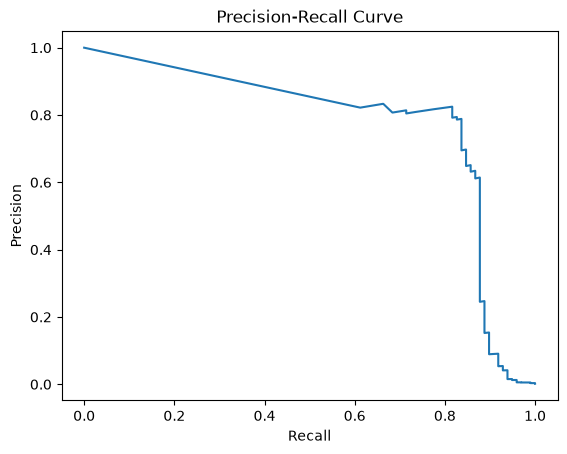

In [128]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_prob) 
plt.plot(recall, precision) 
plt.xlabel('Recall') 
plt.ylabel('Precision') 
plt.title('Precision-Recall Curve')

In [129]:
f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-8)

best_index = np.argmax(f1_scores)
best_threshold = thresholds[best_index]

print(f"Best Threshold: {best_threshold:.4f}")
print(f"Best F1 Score: {f1_scores[best_index]:.4f}")



Best Threshold: 1.0000
Best F1 Score: 0.8205


In [130]:
y_pred_best = (y_pred_prob >= best_threshold).astype(int)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))




Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962




Confusion Matrix:
[[56847    17]
 [   18    80]]


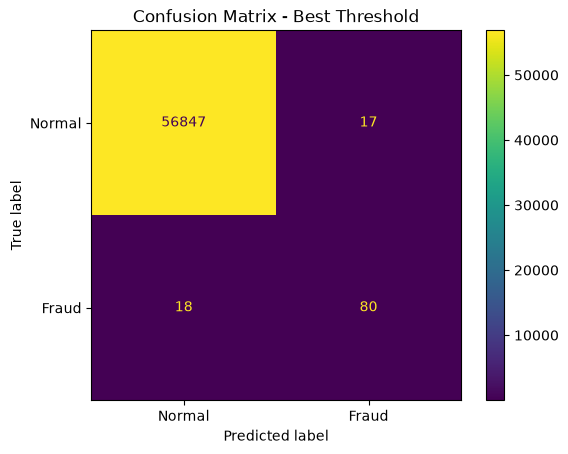

In [131]:
cm = confusion_matrix(y_test, y_pred_best)

print("\nConfusion Matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Fraud"]
).plot()

plt.title("Confusion Matrix - Best Threshold")
plt.show()


In [132]:
import joblib

model_ann.save("model.keras")

joblib.dump(scaler, "scaler.pkl")

joblib.dump(best_threshold, "threshold.pkl")

print("Model, scaler and threshold saved successfully.")

Model, scaler and threshold saved successfully.
